# K-Means

Genero una muestra formada por 3 conjuntos de puntos 

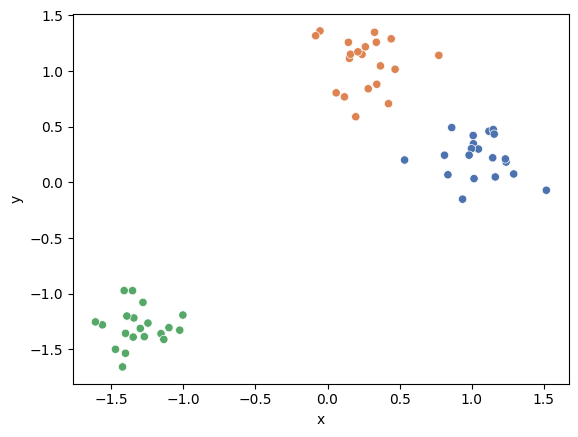

In [12]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
centers = 3
X_train, true_labels = make_blobs(n_samples=60, 
                                  centers=centers, 
                                  random_state=142)
X_train = StandardScaler().fit_transform(X_train)
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=true_labels,
                palette="deep",
                legend=None
                )
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [12]:
num_clusters = 3

### Inicializacion centroides

Voy a asignar de forma manual valores a los centroides para visualizar el proceso que recorre *k-means* para agrupar.

In [13]:
# Vectores con los valores minimo y máximo de cada dimension de los datos de entrada
min_vect, max_vect = np.min(X_train, axis=0), np.max(X_train, axis=0)
# Valores aleatorios distribuidos uniformemente entre el mínimo y el máximo
centroide = [np.random.uniform(min_vect, max_vect) for _ in range(num_clusters)]

In [14]:
centroide=[np.array([-1.12547435, -1.23163784]), np.array([ 1.45476286, -0.33655627]), np.array([ 0.94592174, -0.04368476])]

### Visualizo los puntos y los centroides iniciales

C:\Users\javie\AppData\Local\Temp\ipykernel_22840\2974088320.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=[X[0] for X in X_train],


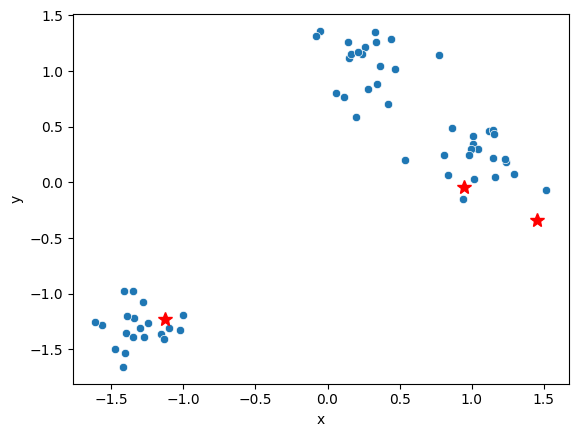

In [ ]:
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                #hue=true_labels,
                #palette="deep",
                legend=None
                )
plt.plot([x for x, _ in centroide],
         [y for _, y in centroide],
         'r*',
         markersize=10,
         )    
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Fijamos el número máximo de iteraciones y inicializamos a nada el valor de la posición anterior de los centroides

In [6]:
max_iter = 100
old_centroide = None
final = False
i_iter = 0

## Proceso iterativo


Sin utilizar `Sklearn` voy a implementar el método *K-Means* para ver que ocurre en cada iteración del modelo.

In [7]:
while not final:
    # Asigno cada punto a su cluster
    # Primero creo una lista de listas. Cada elemento tiene los puntos que le pertenecen
    grupo = [[] for _ in range(num_clusters)]
    for x in X_train:
        # Para cada punto determino la distancia a cada centroide y la guardo en un vector
        dists = [np.linalg.norm(x-centroide[k]) for k in range(num_clusters)]
        centroide_id = np.argmin(dists)
        grupo[centroide_id].append(x)
        
    # Actualizo el valor de cada centroide
    old_centroide = centroide.copy()
    # Calculo la media en cada dimension para cada grupo
    # Si algun grupo no tiene puntos dejo el centroide donde estaba
    for k,grupo_k in enumerate(grupo):
        if len(grupo_k)>0: centroide[k] = np.mean(grupo_k, axis=0)

    # Compruebo convergencia
    i_iter += 1 
    if i_iter == max_iter: final = True    
    difer_centroide = [np.linalg.norm(old_centroide[k]-centroide[k]) for k in range(num_clusters)]
    if max(difer_centroide)<0.00001: final = True
        
print(i_iter, max(difer_centroide))

5 0.0


#### Dibujo el resultado final

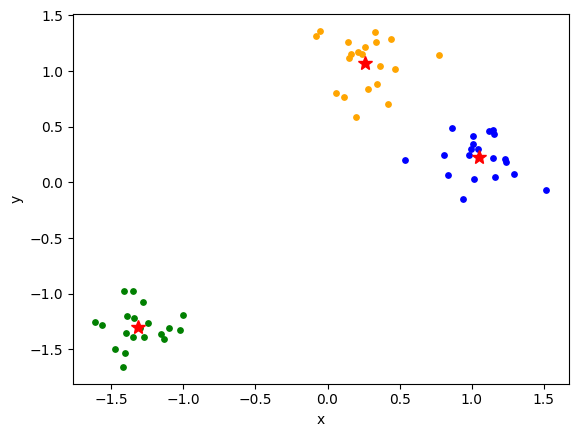

In [8]:
# Reasigno los puntos a los nuevos centroides
grupo = [[] for _ in range(num_clusters)]
for x in X_train:
    # Para cada punto determino la distancia a cada centroide y la guardo en un vector
    dists = [np.linalg.norm(x-centroide[k]) for k in range(num_clusters)]
    centroide_id = np.argmin(dists)
    grupo[centroide_id].append(x)

# Dibujo 
colors = np.array(['g', 'b', 'orange', 'm', 'k', 'y', 'c','lime', 'navy']) 
for k,grupo_k in enumerate(grupo):
    plt.scatter(x=[p[0] for p in grupo_k],y=[p[1] for p in grupo_k],color=colors[k],s=15)
    
plt.plot([x for x, _ in centroide],
         [y for _, y in centroide],
         'r*',
         markersize=10,
         )    
plt.xlabel("x")
plt.ylabel("y")
plt.show()   

## Para dibujar ejecutar en lugar del proceso iterativo

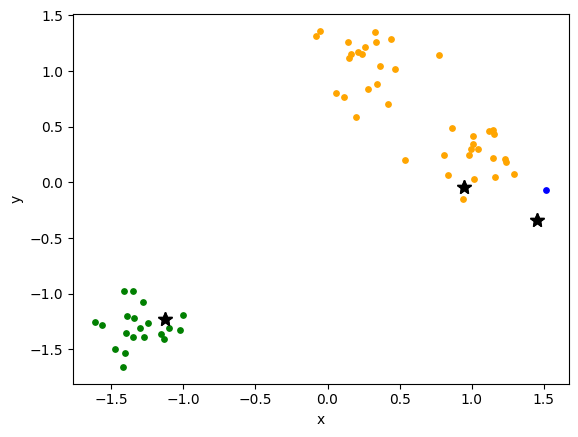

In [16]:
grupo = [[] for _ in range(num_clusters)]
for x in X_train:
    # Para cada punto determino la distancia a cada centroide y la guardo en un vector
    dists = [np.linalg.norm(x-centroide[k]) for k in range(num_clusters)]
    centroide_id = np.argmin(dists)
    grupo[centroide_id].append(x)

# Dibujo 
colors = np.array(['g', 'b', 'orange', 'm', 'k', 'y', 'c','lime', 'navy']) 
for k,grupo_k in enumerate(grupo):
    plt.scatter(x=[p[0] for p in grupo_k],y=[p[1] for p in grupo_k],color=colors[k],s=15)
    
plt.plot([x for x, _ in centroide],
         [y for _, y in centroide],
         'k*',
         markersize=10,
         ) 
plt.plot([x for x, _ in old_centroide],
         [y for _, y in old_centroide],
         'k*', fillstyle= 'none',
         markersize=10,
         )   
plt.xlabel("x")
plt.ylabel("y")
plt.show()   


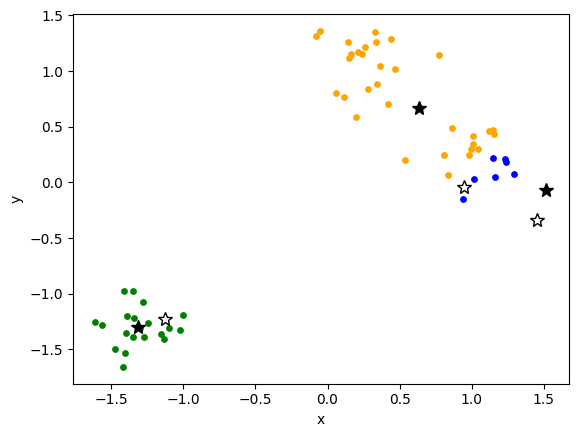

In [7]:
grupo = [[] for _ in range(num_clusters)]
for x in X_train:
    # Para cada punto determino la distancia a cada centroide y la guardo en un vector
    dists = [np.linalg.norm(x-centroide[k]) for k in range(num_clusters)]
    centroide_id = np.argmin(dists)
    grupo[centroide_id].append(x)
        
# Actualizo el valor de cada centroide
old_centroide = centroide.copy()
# Calculo la media en cada dimension para cada grupo
# Si algun grupo no tiene puntos dejo el centroide donde estaba
for k,grupo_k in enumerate(grupo):
    if len(grupo_k)>0: centroide[k] = np.mean(grupo_k, axis=0)

# Compruebo convergencia
i_iter += 1 
if i_iter == max_iter: final = True    
difer_centroide = [np.linalg.norm(old_centroide[k]-centroide[k]) for k in range(num_clusters)]
if max(difer_centroide)<0.00001: final = True
  

# Reasigno los puntos a los nuevos centroides
grupo = [[] for _ in range(num_clusters)]
for x in X_train:
    # Para cada punto determino la distancia a cada centroide y la guardo en un vector
    dists = [np.linalg.norm(x-centroide[k]) for k in range(num_clusters)]
    centroide_id = np.argmin(dists)
    grupo[centroide_id].append(x)

# Dibujo 
colors = np.array(['g', 'b', 'orange', 'm', 'k', 'y', 'c','lime', 'navy']) 
for k,grupo_k in enumerate(grupo):
    plt.scatter(x=[p[0] for p in grupo_k],y=[p[1] for p in grupo_k],color=colors[k],s=15)
    
plt.plot([x for x, _ in centroide],
         [y for _, y in centroide],
         'k*',
         markersize=10,
         ) 
plt.plot([x for x, _ in old_centroide],
         [y for _, y in old_centroide],
         'k*', fillstyle= 'none',
         markersize=10,
         )   
plt.xlabel("x")
plt.ylabel("y")
plt.show()   


# K-Means usando `SKlearn`

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score

### Creo un conjunto de datos con 2 grupos.

<Axes: >

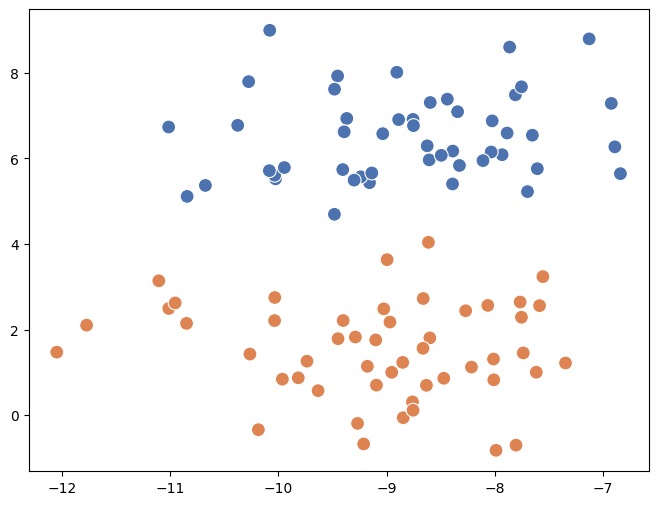

In [2]:
# Generar datos
n_clusteres = 2
X_train, true_labels = make_blobs(n_samples=100, centers=n_clusteres, random_state=342)

# Crear una figura
plt.figure(figsize=(8, 6))

# Primer scatter plot con las etiquetas originales
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=true_labels,
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=100  # Tamaño de los puntos
                )

## Clase `KMeans` en `Sklearn`

Creamos un objeto de la clase `KMeans` de `sklearn` para realizar un *clustering* (agrupamiento) usando el algoritmo de *K-means*.

* `n_clusters` Este parámetro define el número de clusters que deseas identificar en tus datos. En este caso, se está usando una variable n_clusteres, que indica cuántos clusters queremos formar.

* `init=`: El parámetro init especifica cómo se deben inicializar los centroides de los clusters al inicio del algoritmo de K-means. Este parámetro tiene diferentes opciones:
    * `'random'` significa que los centroides iniciales se eligen aleatoriamente a partir de los puntos de datos.
    * `'k-means++'` (valor por defecto): Este método selecciona los centroides iniciales de manera que se minimice la probabilidad de obtener un mal resultado. Seleccionamos aleatoriamente el primer centroide. El resto se calculan de forma que su distancia a los centroides existentes se distribuya uniformemente. 
    * `array`: Si proporcionas un `np.array`, los centroides iniciales serán los puntos especificados en ese array.

* `n_init=`: (Con `init= 'random'`) Controla cuántas veces se debe ejecutar el algoritmo de *K-means* con diferentes inicializaciones de los centroides. El algoritmo seleccionará la mejor solución en función de la inercia (la distancia total dentro de los clusters).

* `max_iter=`: Controla el número máximo de iteraciones que el algoritmo realizará para encontrar la solución final (300 por defecto).

In [3]:
# Aplicar KMeans
kmeans = KMeans(n_clusters=n_clusteres, init='random', n_init=15, max_iter=50)
#kmeans = KMeans(n_clusters=n_clusteres, init='k-means++',  max_iter=50)


### Métodos más importantes en la clase `KMeans`

* `fit(X)`:  Este es el método que realiza el clustering propiamente dicho, es decir, que encuentra los centroides de los clusters y asigna cada punto a un cluster.
Parámetros:
    * `X`: Matriz de características (también llamada datos de entrada). De tamaño `[n_samples,n_features]`.
Devuelve el objeto KMeans con los resultados del entrenamiento (los centroides y las etiquetas de los clusters).

* `predict(X)`: Una vez que el modelo ha sido ajustado usando `fit()` predice qué cluster pertenece cada punto nuevo en X.

Devuelve un *array*  de etiquetas de cluster, donde cada elemento corresponde al cluster asignado al punto.

* `fit_predict(X)`: Combina `fit()` y `predict()` en un solo paso. Primero ajusta el modelo a los datos y luego predice las etiquetas de los clusters para esos mismos datos.

* `score(X)`: Calcula la distancia intra-cluster *WCSS* del modelo, que es una medida de la calidad del clustering. El *WCSS* se calcula como la suma de las distancias cuadradas de cada punto a su centroide más cercano.

* `inertia_`: Es un atributo, no un método, que devuelve  el "error cuadrático medio" *WCSS* del modelo. Es la misma que el valor retornado por el método `score()`, pero aquí no necesitas pasar los datos como parámetro, ya que se calcula cuando el modelo es ajustado.

* `cluster_centers_`: Atributo que da las coordenadas de los centroides de los clusters después de que el modelo ha sido ajustado. Proporciona las coordenadas en forma de matriz donde cada fila contiene las coordenadas de un centroide.

In [4]:
labels = kmeans.fit_predict(X_train)

### Visualización de resultados.

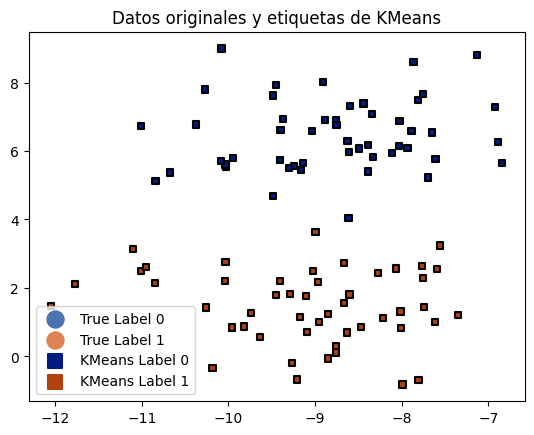

In [6]:
sns.scatterplot(x=[X[0] for X in X_train],
                y=[X[1] for X in X_train],
                hue=labels,
                palette="dark",
                marker="s",  # Diferente marcador para etiquetas KMeans
                facecolor="none",  # Marcadores no rellenados
                edgecolor="k",  # Color del borde
                linewidth=1.5,
                legend=None,
                s=20  # Tamaño de los puntos
                )

# Añadir leyendas manualmente para diferenciar los dos conjuntos de datos
for label, color in zip(np.unique(true_labels), sns.color_palette("deep", n_clusteres)):
    plt.scatter([], [], color=color, label=f'True Label {label}', marker='o', s=150)

for label, color in zip(np.unique(labels), sns.color_palette("dark", n_clusteres)):
    plt.scatter([], [], edgecolor=color , color=color,  label=f'KMeans Label {label}', marker='s', linewidth=1.5, s=100)

# Mostrar la leyenda
plt.legend()

# Mostrar la gráfica
plt.title('Datos originales y etiquetas de KMeans')
plt.show()

## Efecto de la normalización

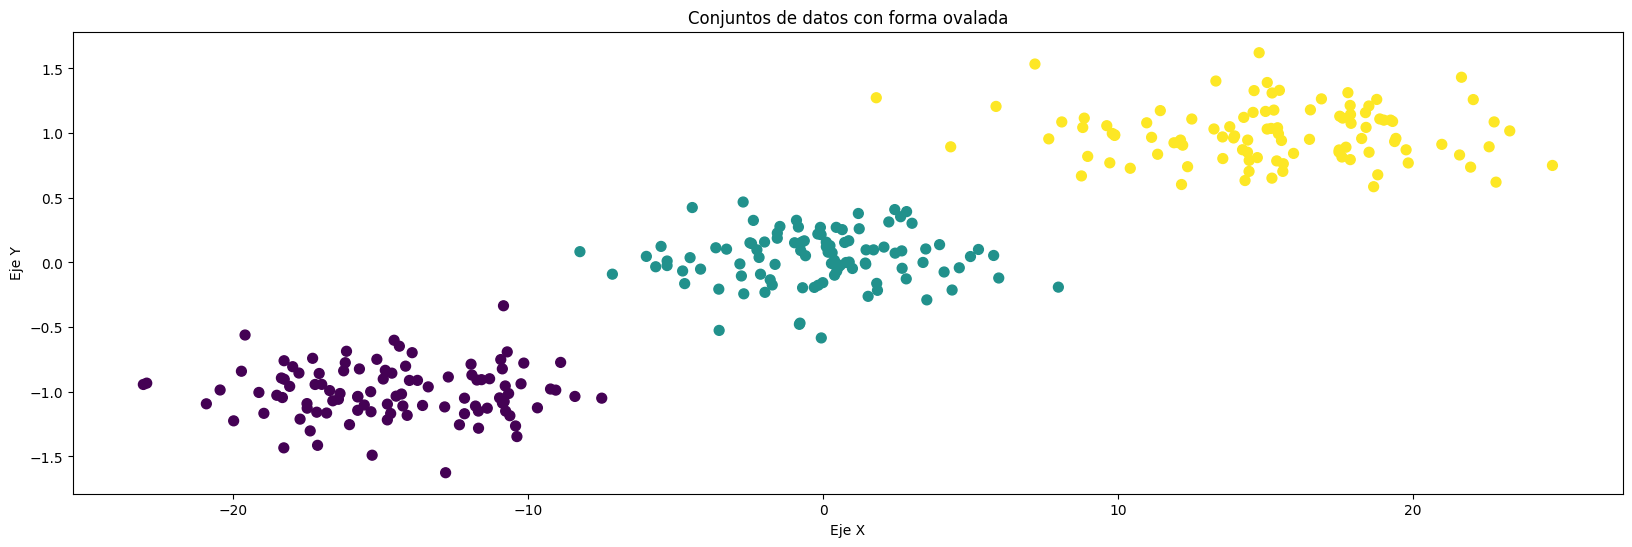

In [7]:
# Parámetros para los blobs
centros = [(-15, -1), (0, 0), (15, 1)]
n_samples = 300  # Número total de muestras
cluster_std = [(3.4, 0.2), (3.2, 0.2), (4.2, 0.2)]  # Desviaciones estándar en x y en y

# Crear blobs
X, y = make_blobs(n_samples=n_samples, centers=centros, cluster_std=[std for std in cluster_std], random_state=532)

# Crear una figura para los gráficos
plt.figure(figsize=(20, 6))

# Graficar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjuntos de datos con forma ovalada')
plt.show() 

#### Algoritmo *K-Means* sin normalizar

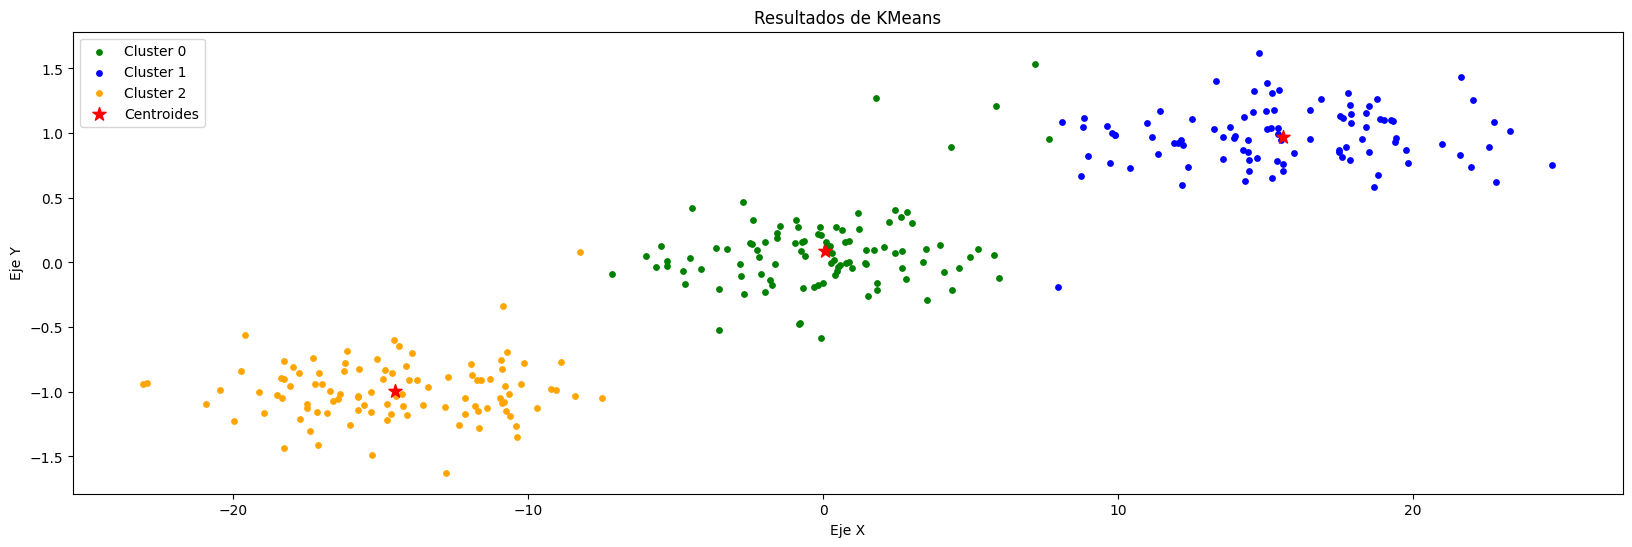

In [8]:
kmeans = KMeans(n_clusters=3, max_iter=50)
labels = kmeans.fit_predict(X)

colors = ['g', 'b', 'orange', 'm', 'k', 'y', 'c','lime', 'navy']
# Graficar los puntos de datos coloreados por cluster
plt.figure(figsize=(20, 6))
for label in np.unique(labels):
    plt.scatter(X[labels == label, 0], X[labels == label, 1], color=colors[label], s=15, label=f'Cluster {label}')

# Graficar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='r', s=100, marker='*', label='Centroides')

# Añadir etiquetas y título
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Resultados de KMeans')
plt.legend()
plt.show()    



#### Algoritmo *K-Means* despues de normalizar los datos de entrada

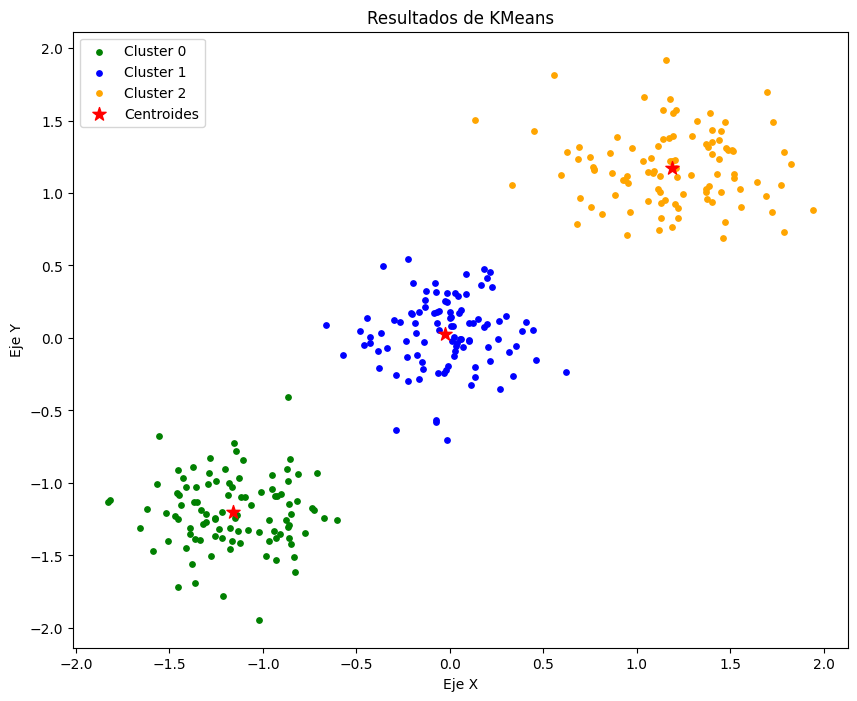

In [9]:
X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, max_iter=50)
labels = kmeans.fit_predict(X)

colors = ['g', 'b', 'orange', 'm', 'k', 'y', 'c','lime', 'navy']
# Graficar los puntos de datos coloreados por cluster
plt.figure(figsize=(10, 8))
for label in np.unique(labels):
    plt.scatter(X[labels == label, 0], X[labels == label, 1], color=colors[label], s=15, label=f'Cluster {label}')

# Graficar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='r', s=100, marker='*', label='Centroides')

# Añadir etiquetas y título
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Resultados de KMeans')
plt.legend()
plt.show()   

### Cálculo del número óptimo de grupos (*clusters*)

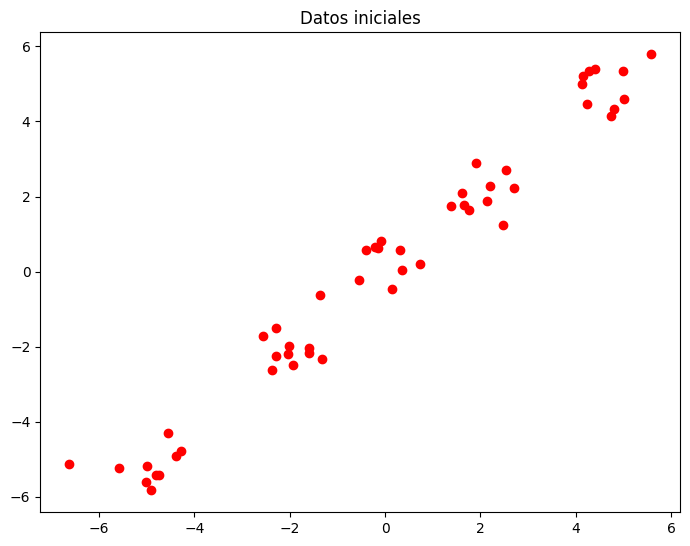

In [13]:
from numpy.random import default_rng
rng = default_rng(1513)
# generating data (that I know comes from two groups)
X1 = rng.normal(loc=2.0, scale=0.5, size=20).reshape((10, 2))
X2 = rng.normal(loc=-2.0, scale=0.5, size=20).reshape((10, 2))
X3 = rng.normal(loc=-5.0, scale=0.5, size=20).reshape((10, 2))
X4 = rng.normal(loc=5.0, scale=0.5, size=20).reshape((10, 2))
X5 = rng.normal(loc=0.0, scale=0.5, size=20).reshape((10, 2))
dummy_data = np.vstack([X1, X2, X3, X4, X5])
data = pd.DataFrame(dummy_data, columns=['x', 'y'])

fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
ax.scatter(data.x, data.y, c='r'); 
ax.set_title('Datos iniciales');

#### Método del codo usando el atributo`kmeans.inertia_`

[1169.923683152767, 366.25916366413793, 153.88493998100486, 55.580745600848466, 22.441377097580748, 21.418514587600658, 19.416562108643216, 15.005593642261463, 12.909970086144664, 11.2219227439753, 9.291852412087477, 7.819327614330153, 7.359484937710146, 5.942448113592014]


Text(0, 0.5, 'WCSS')

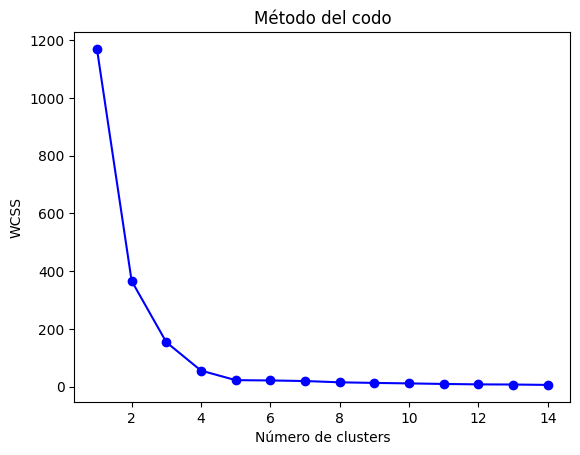

In [14]:
num_cluster = list(range(1,15))
wcss = [] 
for i in num_cluster: 
    kmeans = KMeans(n_clusters = i, random_state = 42)
    labels = kmeans.fit_predict(data) 
    wcss.append(kmeans.inertia_)

print(wcss)
plt.figure()
plt.plot(num_cluster, wcss,'b-') 
plt.scatter(num_cluster, wcss, color='blue')  # Puntos
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')

#### Gráfico de la solución con el número óptimo de centroides

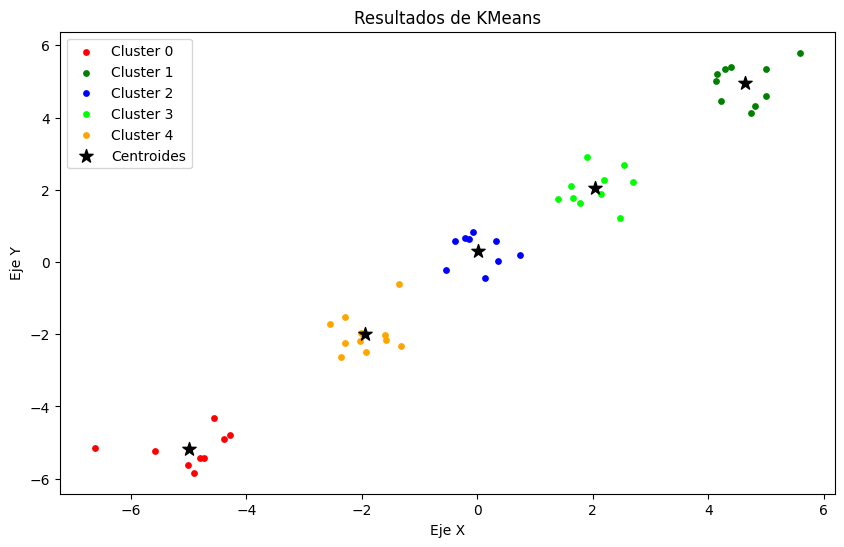

In [15]:
kmeans = KMeans(n_clusters=5, max_iter=50)
labels = kmeans.fit_predict(data)
data["label"] = labels

colors = ['r','g','b','lime', 'orange']
plt.figure(figsize=(10, 6))
for label_ in np.unique(labels):
    x_ = data[data["label"] == label_].x
    y_ = data[data["label"] == label_].y
    plt.scatter(x_, y_, color=colors[label_], s=15, label=f'Cluster {label_}')

# Graficar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='k', s=100, marker='*', label='Centroides')

# Añadir etiquetas y título
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Resultados de KMeans')
plt.legend()
plt.show()   

### Método de la silueta (*Silhouette*) en *K-Means*

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

Creamos un conjunto de datos para agrupar

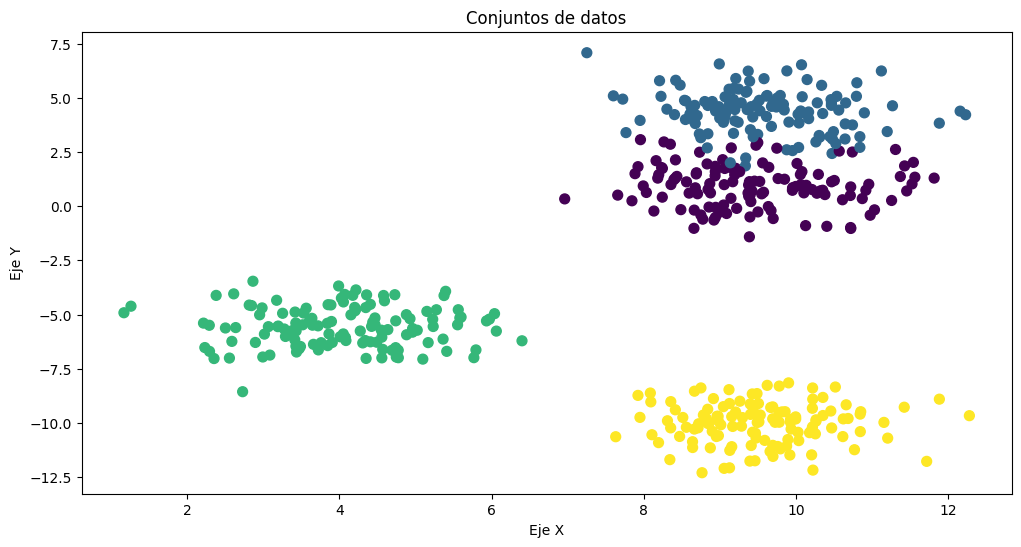

In [16]:
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=4,
)  # For reproducibility

# Crear una figura para los gráficos
plt.figure(figsize=(12, 6))

# Graficar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Conjuntos de datos')
plt.show() 

Uso `silhouette_score()` para evaluar el SSC de cada punto y promediarlo por clúster.
Uso `silhouette_samples()` para hacer una gráfica de la silueta de cad punto.

For n_clusters = 2 The average silhouette_score is : 0.6768373972275579
For n_clusters = 3 The average silhouette_score is : 0.7417215720827383
For n_clusters = 4 The average silhouette_score is : 0.6463589049792018
For n_clusters = 5 The average silhouette_score is : 0.5747041706492425
For n_clusters = 6 The average silhouette_score is : 0.4572936810133809


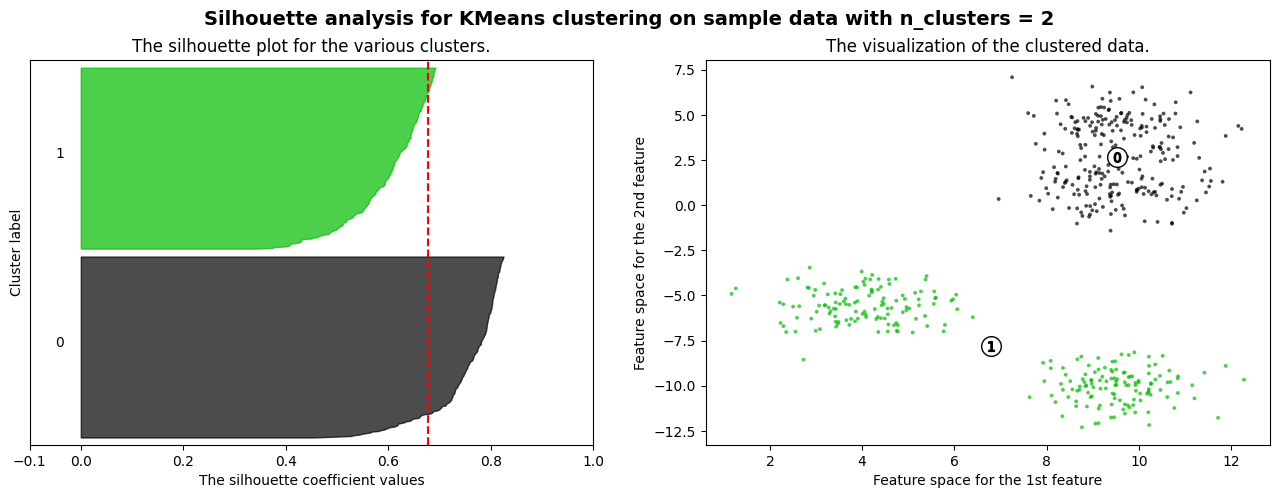

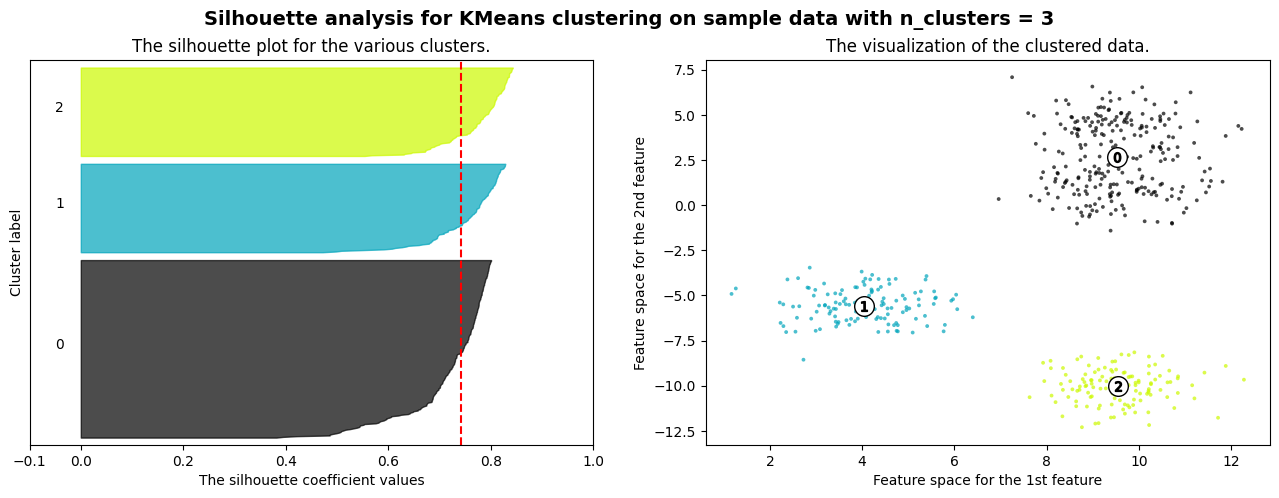

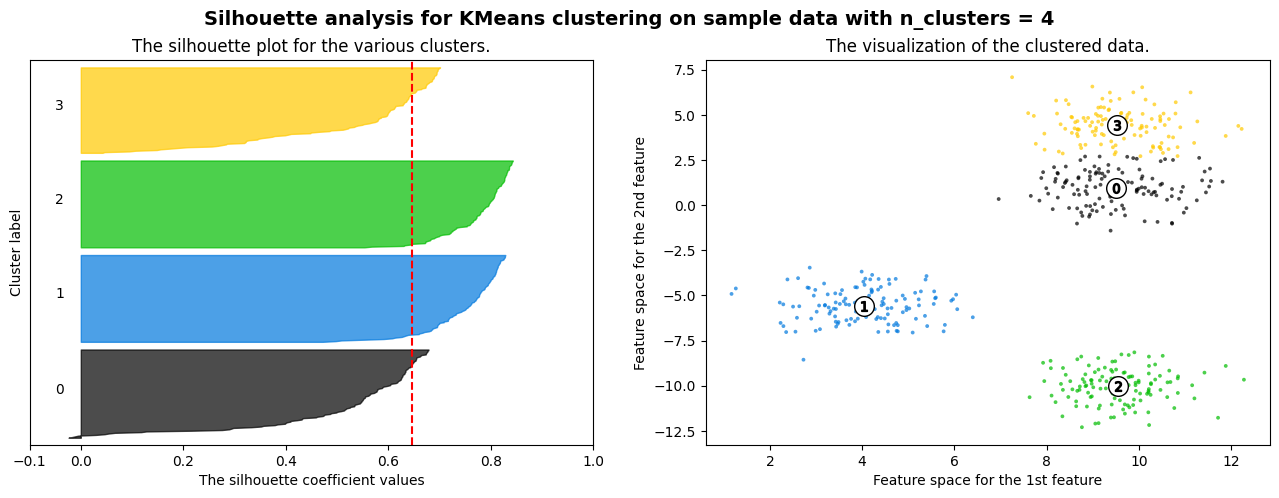

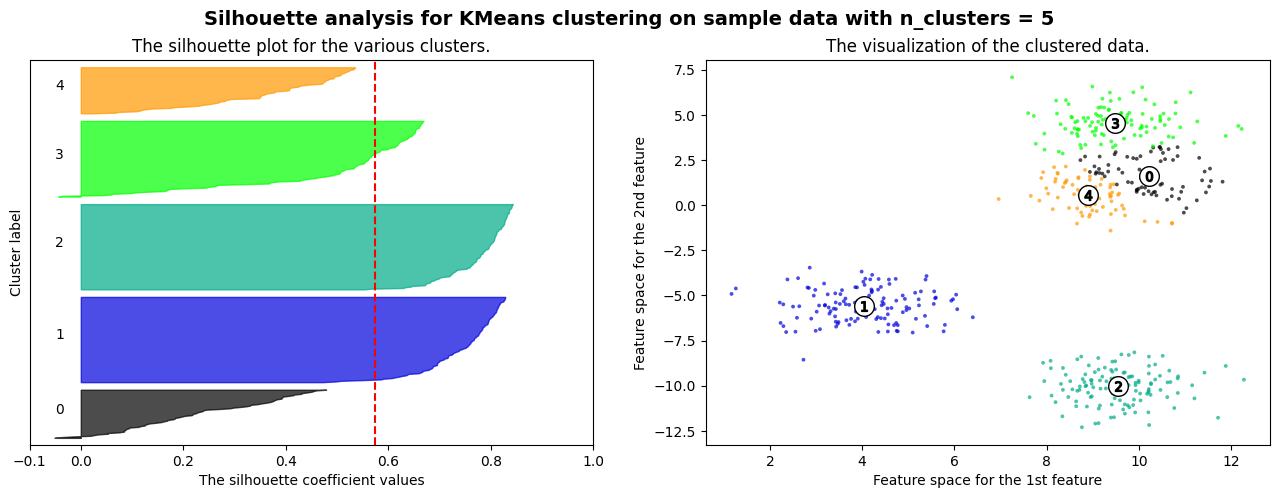

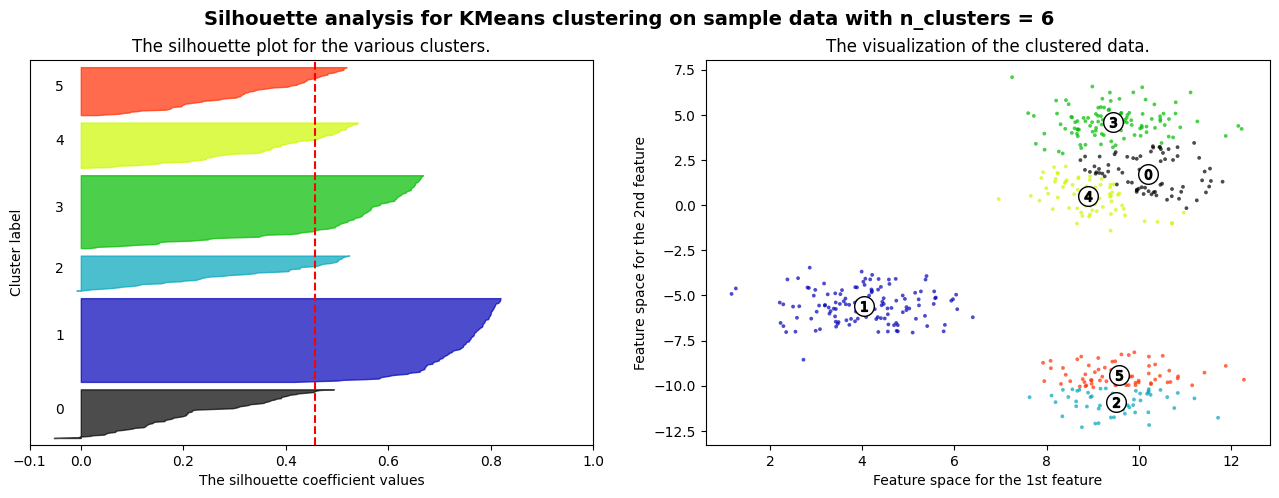

In [18]:
import matplotlib.cm as cm

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(16, 5)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()